# 🧠 NeuroExplain — Neurological Disease Prediction Pipeline

**Architecture:**
```
Dataset → Preprocessing → Augmentation → Train/Test Split
  → Deep Learning Model Training (ResNet50 | EfficientNetB3 | MobileNetV2)
  → Feature Extraction → Feature Fusion → Ensemble Classification
  → Disease Prediction + Grad-CAM Explainability
```

**Models Used:** ResNet50 · EfficientNetB3 · MobileNetV2  
**Explainability:** Grad-CAM  
**Dataset Classes:** Alzheimer · Stroke (Haemorrhagic / Ischaemic) · [auto-detected from folder names]

> **Change vs. previous version:** DenseNet121 has been replaced with MobileNetV2.
> MobileNetV2 has fewer parameters (3.5M vs DenseNet's 8M), trains faster, and on
> small-to-medium medical-imaging datasets typically generalises better when
> fine-tuned end-to-end.


## ⚙️ Step 0 — Environment Setup

In [ ]:
# Install dependencies
!pip install -q grad-cam==1.4.8 torchmetrics scikit-learn matplotlib seaborn
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

import os, zipfile, shutil, random, json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
import torch.nn.functional as F

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')
print(f'✅ CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 68.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 12.6 MB/s eta 0:00:00
✅ Device: cuda
✅ CUDA available: True
   GPU: Tesla T4


## 📦 Step 1 — Upload & Extract Dataset

Mounted at /content/drive
✅ Dataset extracted successfully!

📁 Dataset root: /content/dataset/TOTTAL_DISESASES

🏷️ Classes found (4): ['Alzheimer', 'Brain Tumor', 'Multiple Sclerosis', 'Normal']
   Alzheimer: 1104 images
   Brain Tumor: 1125 images
   Multiple Sclerosis: 1003 images
   Normal: 1132 images


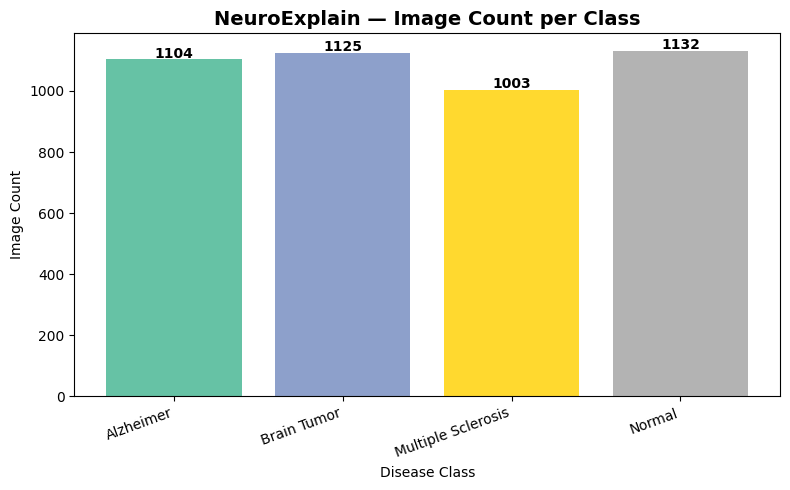


✅ Dataset loaded successfully from Google Drive!


In [ ]:
from google.colab import drive
from pathlib import Path
import zipfile
import matplotlib.pyplot as plt
import numpy as np

# Mount Google Drive
drive.mount('/content/drive')

# Path to your ZIP file in Google Drive
# Example: /content/drive/MyDrive/TOTTAL_DISESASES.zip
ZIP_PATH = '/content/drive/MyDrive/TOTTAL_DISESASES.zip'

# Extraction folder
EXTRACT_DIR = Path('/content/dataset')
EXTRACT_DIR.mkdir(exist_ok=True)

# Extract ZIP
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

print("✅ Dataset extracted successfully!")

# Auto-detect root folder inside zip
subdirs = [d for d in EXTRACT_DIR.iterdir() if d.is_dir()]
DATA_ROOT = subdirs[0] if subdirs else EXTRACT_DIR

print(f'\n📁 Dataset root: {DATA_ROOT}')

# Discover classes
CLASS_DIRS = sorted([d for d in DATA_ROOT.iterdir() if d.is_dir()])
CLASSES = [d.name for d in CLASS_DIRS]
NUM_CLASSES = len(CLASSES)

print(f'\n🏷️ Classes found ({NUM_CLASSES}): {CLASSES}')

# Count images per class
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

class_counts = {}

for cls_dir in CLASS_DIRS:
    imgs = [f for f in cls_dir.rglob('*') if f.suffix.lower() in IMG_EXTS]
    class_counts[cls_dir.name] = len(imgs)
    print(f'   {cls_dir.name}: {len(imgs)} images')

# Plot class distribution
plt.figure(figsize=(max(8, NUM_CLASSES * 1.5), 5))

colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))

plt.bar(class_counts.keys(), class_counts.values(), color=colors)

plt.title(
    'NeuroExplain — Image Count per Class',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Disease Class')
plt.ylabel('Image Count')

plt.xticks(rotation=20, ha='right')

for i, (k, v) in enumerate(class_counts.items()):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()

# Save graph
plt.savefig('/content/class_distribution.png', dpi=150)

plt.show()

print('\n✅ Dataset loaded successfully from Google Drive!')

## 🔧 Step 2 — Data Preprocessing & Augmentation

Train: 3054 | Val: 655 | Test: 655

✅ DataLoaders ready


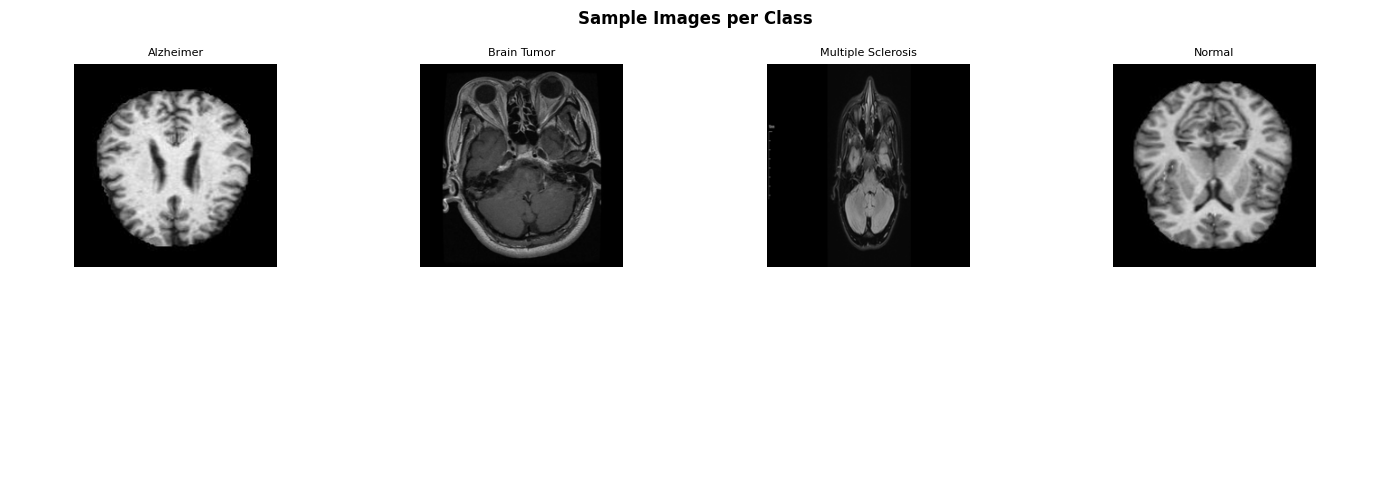

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

# ── Collect all image paths + labels ──────────────────────────────────────────
all_paths, all_labels = [], []
for idx, cls_dir in enumerate(CLASS_DIRS):
    imgs = [f for f in cls_dir.rglob('*') if f.suffix.lower() in IMG_EXTS]
    all_paths.extend(imgs)
    all_labels.extend([idx] * len(imgs))

# Stratified split: train / val / test
paths_train, paths_temp, y_train, y_temp = train_test_split(
    all_paths, all_labels, test_size=VAL_SPLIT+TEST_SPLIT,
    stratify=all_labels, random_state=SEED
)
paths_val, paths_test, y_val, y_test = train_test_split(
    paths_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
)
print(f'Train: {len(paths_train)} | Val: {len(paths_val)} | Test: {len(paths_test)}')

# ── Transforms ────────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE+20, IMG_SIZE+20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=0, shear=10, scale=(0.85, 1.15)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Custom Dataset ─────────────────────────────────────────────────────────────
class NeuroDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = Image.open(self.paths[idx]).convert('RGB')
        except Exception:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (128, 128, 128))
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

train_ds = NeuroDataset(paths_train, y_train, train_transform)
val_ds   = NeuroDataset(paths_val,   y_val,   val_test_transform)
test_ds  = NeuroDataset(paths_test,  y_test,  val_test_transform)

# Weighted sampler for class imbalance
counts = Counter(y_train)
weights = [1.0 / counts[l] for l in y_train]
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, drop_last=True)

print('\n✅ DataLoaders ready')

# Visualise sample images
fig, axes = plt.subplots(2, min(5, NUM_CLASSES*2 // 2), figsize=(14, 5))
axes = axes.flatten()
for ax, (cls_dir, cls_name) in zip(axes, [(d, d.name) for d in CLASS_DIRS]):
    sample_imgs = [f for f in cls_dir.rglob('*') if f.suffix.lower() in IMG_EXTS][:1]
    if sample_imgs:
        img = Image.open(sample_imgs[0]).convert('RGB').resize((224, 224))
        ax.imshow(img); ax.set_title(cls_name, fontsize=8)
    ax.axis('off')
for ax in axes[NUM_CLASSES:]: ax.axis('off')
plt.suptitle('Sample Images per Class', fontweight='bold')
plt.tight_layout(); plt.savefig('/content/sample_images.png', dpi=150)
plt.show()

## 🏗️ Step 3 — Model Definitions (ResNet50 | EfficientNetB3 | MobileNetV2)

In [ ]:
def build_resnet50(num_classes):
    """ResNet-50 with custom head + dropout."""
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    for p in list(model.parameters())[:-20]:  # Unfreeze last ~20 params
        p.requires_grad = False
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, num_classes)
    )
    return model

def build_efficientnet_b3(num_classes):
    """EfficientNet-B3 with custom classifier."""
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    for p in list(model.parameters())[:-30]:
        p.requires_grad = False
    in_feats = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_feats, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return model

def build_mobilenetv2(num_classes):
    """MobileNet-V2 with custom classifier (replaces DenseNet121)."""
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V2)
    # Unfreeze last ~30 parameters (matches DenseNet121 fine-tuning depth)
    for p in list(model.parameters())[:-30]:
        p.requires_grad = False
    in_feats = model.classifier[-1].in_features  # 1280
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_feats, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, num_classes)
    )
    return model

print('✅ Model builders defined: ResNet50 | EfficientNetB3 | MobileNetV2')


✅ Model builders defined: ResNet50 | EfficientNetB3 | MobileNetV2


## 🏋️ Step 4 — Training Loop with Early Stopping

In [ ]:
class EarlyStopping:
    def __init__(self, patience=7, delta=1e-4):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.counter = 0
        self.stop = False

    def __call__(self, val_loss):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_score = score
            self.counter = 0


def train_model(model, name, train_loader, val_loader,
                num_epochs=30, lr=1e-4, patience=7):
    model = model.to(DEVICE)

    # Class-weighted loss
    cls_counts = torch.tensor([counts[i] for i in range(NUM_CLASSES)], dtype=torch.float)
    cls_weights = (1.0 / cls_counts).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=cls_weights)

    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    early_stop = EarlyStopping(patience=patience)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_path = f'/content/{name}_best.pth'

    print(f'\n{'='*60}')
    print(f'  Training: {name}')
    print(f'{'='*60}')

    for epoch in range(num_epochs):
        # ── TRAIN ──
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item() * imgs.size(0)
            t_correct += (out.argmax(1) == labels).sum().item()
            t_total += imgs.size(0)

        # ── VALIDATE ──
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out = model(imgs)
                loss = criterion(out, labels)
                v_loss += loss.item() * imgs.size(0)
                v_correct += (out.argmax(1) == labels).sum().item()
                v_total += imgs.size(0)

        tr_loss = t_loss / t_total
        val_loss = v_loss / v_total
        tr_acc = t_correct / t_total
        val_acc = v_correct / v_total

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)

        scheduler.step()
        early_stop(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_path)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'  Ep {epoch+1:3d}/{num_epochs} | '
                  f'TrLoss: {tr_loss:.4f} TrAcc: {tr_acc:.3f} | '
                  f'ValLoss: {val_loss:.4f} ValAcc: {val_acc:.3f}')

        if early_stop.stop:
            print(f'  Early stopping at epoch {epoch+1}')
            break

    print(f'  Best Val Acc: {best_val_acc:.4f} → saved to {best_path}')
    model.load_state_dict(torch.load(best_path))
    return model, history

print('✅ Training loop defined')

✅ Training loop defined


## 🚀 Step 5 — Train All Three Models

In [ ]:
NUM_EPOCHS = 30  # Increase to 50+ for better results

# ── ResNet-50 ─────────────────────────────────────────────────────────────────
resnet_model, resnet_hist = train_model(
    build_resnet50(NUM_CLASSES), 'ResNet50',
    train_loader, val_loader, num_epochs=NUM_EPOCHS, lr=1e-4
)

# ── EfficientNet-B3 ───────────────────────────────────────────────────────────
effnet_model, effnet_hist = train_model(
    build_efficientnet_b3(NUM_CLASSES), 'EfficientNetB3',
    train_loader, val_loader, num_epochs=NUM_EPOCHS, lr=5e-5
)

# ── MobileNet-V2 (replaces DenseNet121) ───────────────────────────────────────
mobilenet_model, mobilenet_hist = train_model(
    build_mobilenetv2(NUM_CLASSES), 'MobileNetV2',
    train_loader, val_loader, num_epochs=NUM_EPOCHS, lr=1e-4
)

print('\n✅ All three models trained!')


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]



  Training: ResNet50
  Ep   1/30 | TrLoss: 0.3581 TrAcc: 0.877 | ValLoss: 0.2169 ValAcc: 0.931
  Ep   5/30 | TrLoss: 0.1083 TrAcc: 0.962 | ValLoss: 0.0964 ValAcc: 0.966
  Ep  10/30 | TrLoss: 0.0813 TrAcc: 0.971 | ValLoss: 0.0558 ValAcc: 0.983
  Ep  15/30 | TrLoss: 0.0521 TrAcc: 0.980 | ValLoss: 0.0420 ValAcc: 0.992
  Ep  20/30 | TrLoss: 0.0413 TrAcc: 0.984 | ValLoss: 0.0453 ValAcc: 0.986
  Early stopping at epoch 22
  Best Val Acc: 0.9922 → saved to /content/ResNet50_best.pth
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 211MB/s]



  Training: EfficientNetB3
  Ep   1/30 | TrLoss: 0.9804 TrAcc: 0.721 | ValLoss: 7.2546 ValAcc: 0.847
  Ep   5/30 | TrLoss: 0.1806 TrAcc: 0.936 | ValLoss: 0.1898 ValAcc: 0.923
  Ep  10/30 | TrLoss: 0.1522 TrAcc: 0.943 | ValLoss: 0.1695 ValAcc: 0.925
  Ep  15/30 | TrLoss: 0.1404 TrAcc: 0.944 | ValLoss: 33.3182 ValAcc: 0.939
  Ep  20/30 | TrLoss: 0.1332 TrAcc: 0.947 | ValLoss: 0.1446 ValAcc: 0.941
  Ep  25/30 | TrLoss: 0.1291 TrAcc: 0.952 | ValLoss: 0.1406 ValAcc: 0.941
  Early stopping at epoch 26
  Best Val Acc: 0.9406 → saved to /content/EfficientNetB3_best.pth
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 174MB/s]


  Training: MobileNetV2


  Ep   1/30 | TrLoss: 0.4429 TrAcc: 0.846 | ValLoss: 0.2244 ValAcc: 0.952
  Ep   5/30 | TrLoss: 0.0935 TrAcc: 0.966 | ValLoss: 0.0985 ValAcc: 0.966
  Ep  10/30 | TrLoss: 0.0694 TrAcc: 0.977 | ValLoss: 0.0948 ValAcc: 0.966
  Ep  15/30 | TrLoss: 0.0568 TrAcc: 0.978 | ValLoss: 0.1041 ValAcc: 0.961
  Ep  20/30 | TrLoss: 0.0563 TrAcc: 0.980 | ValLoss: 0.1040 ValAcc: 0.967
  Ep  25/30 | TrLoss: 0.0564 TrAcc: 0.982 | ValLoss: 0.0933 ValAcc: 0.970
  Early stopping at epoch 25
  Best Val Acc: 0.9797 → saved to /content/MobileNetV2_best.pth

✅ All three models trained!


## 📊 Step 6 — Training Curves

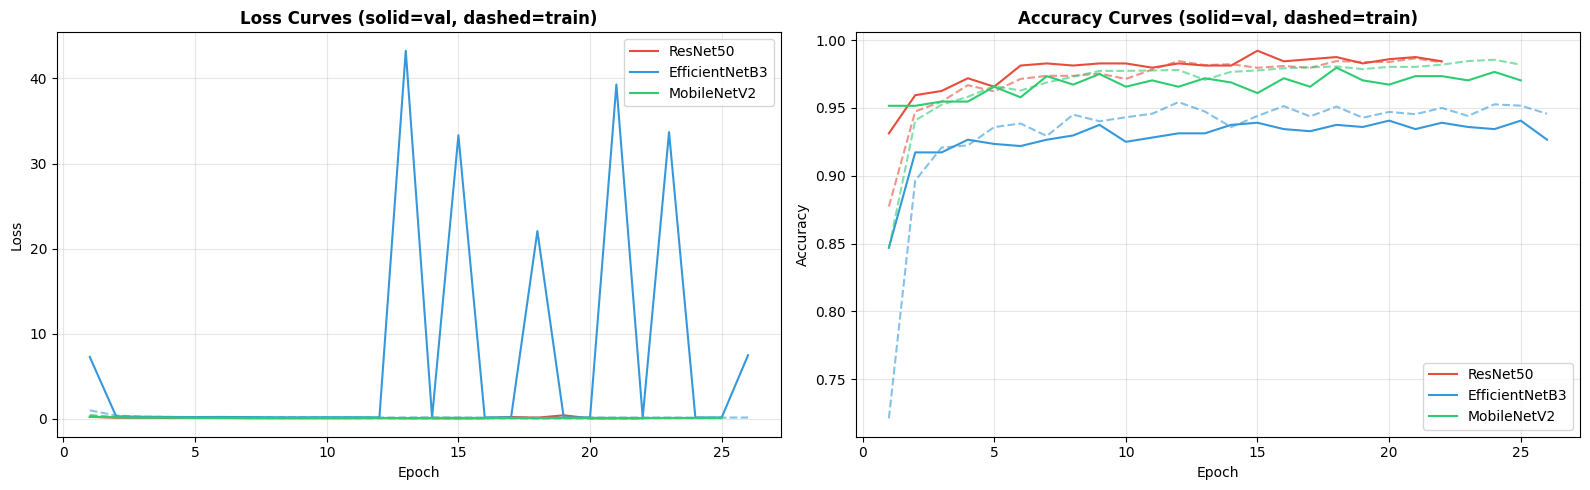

In [ ]:
def plot_history(histories, names):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    colors = ['#e74c3c', '#3498db', '#2ecc71']

    for hist, name, c in zip(histories, names, colors):
        epochs = range(1, len(hist['train_loss']) + 1)
        axes[0].plot(epochs, hist['train_loss'], '--', color=c, alpha=0.6)
        axes[0].plot(epochs, hist['val_loss'], '-', color=c, label=name)
        axes[1].plot(epochs, hist['train_acc'], '--', color=c, alpha=0.6)
        axes[1].plot(epochs, hist['val_acc'], '-', color=c, label=name)

    axes[0].set_title('Loss Curves (solid=val, dashed=train)', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].set_title('Accuracy Curves (solid=val, dashed=train)', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/training_curves.png', dpi=150)
    plt.show()

plot_history(
    [resnet_hist, effnet_hist, mobilenet_hist],
    ['ResNet50', 'EfficientNetB3', 'MobileNetV2']
)


## 🔬 Step 7 — Feature Extraction & Fusion

In [ ]:
import pandas as pd
import os

# ── Feature extractors (strip final classifier) ────────────────────────────────
class FeatureExtractor(nn.Module):
    def __init__(self, backbone, arch):
        super().__init__()
        self.arch = arch
        if arch == 'resnet':
            self.features = nn.Sequential(*list(backbone.children())[:-1])
            self.feat_dim = 2048
        elif arch == 'effnet':
            self.features = backbone.features
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.feat_dim = 1536
        elif arch == 'mobilenet':
            # MobileNetV2: backbone.features → (B, 1280, 7, 7) for 224x224 input
            self.features = backbone.features
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.feat_dim = 1280

    def forward(self, x):
        if self.arch == 'resnet':
            return self.features(x).squeeze(-1).squeeze(-1)
        else:
            # effnet / mobilenet: features → pool → flatten
            x = self.features(x)
            return self.pool(x).squeeze(-1).squeeze(-1)


def extract_features(model, arch, loader):
    extractor = FeatureExtractor(model, arch).to(DEVICE)
    extractor.eval()
    feats, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            f = extractor(imgs)
            feats.append(f.cpu().numpy())
            labels_all.extend(labels.numpy())
    return np.concatenate(feats, axis=0), np.array(labels_all)


print('Extracting ResNet50 features...')
feats_r_train, lbls_train = extract_features(resnet_model, 'resnet', train_loader)
feats_r_test,  lbls_test  = extract_features(resnet_model, 'resnet', test_loader)

print('Extracting EfficientNetB3 features...')
feats_e_train, _ = extract_features(effnet_model, 'effnet', train_loader)
feats_e_test,  _ = extract_features(effnet_model, 'effnet', test_loader)

print('Extracting MobileNetV2 features...')
feats_m_train, _ = extract_features(mobilenet_model, 'mobilenet', train_loader)
feats_m_test,  _ = extract_features(mobilenet_model, 'mobilenet', test_loader)

# ── Feature fusion (concatenate along axis=1) ─────────────────────────────────
fused_train = np.concatenate([feats_r_train, feats_e_train, feats_m_train], axis=1)
fused_test  = np.concatenate([feats_r_test,  feats_e_test,  feats_m_test],  axis=1)

print(f'\nFused feature dim: {fused_train.shape[1]} '
      f'(ResNet50:2048 + EfficientNetB3:1536 + MobileNetV2:1280)')
print(f'Train fused: {fused_train.shape}  |  Test fused: {fused_test.shape}')

# Save fused features as CSVs (compatible with downstream classifier pipelines)
feat_cols = [f'f{i}' for i in range(fused_train.shape[1])]
pd.DataFrame(np.column_stack([fused_train, lbls_train]),
             columns=feat_cols + ['label']).to_csv(
    '/content/fused_train_features_NDD.csv', index=False)
pd.DataFrame(np.column_stack([fused_test, lbls_test]),
             columns=feat_cols + ['label']).to_csv(
    '/content/fused_test_features_NDD.csv', index=False)
print('✅ Fused features saved to /content/fused_*_features_NDD.csv')


Extracting ResNet50 features...
Extracting EfficientNetB3 features...
Extracting MobileNetV2 features...

Fused feature dim: 4864 (ResNet50:2048 + EfficientNetB3:1536 + MobileNetV2:1280)
Train fused: (3040, 4864)  |  Test fused: (640, 4864)
✅ Fused features saved to /content/fused_*_features_NDD.csv


## 🎯 Step 8 — Ensemble Classification

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Normalise fused features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(fused_train)
X_test_sc  = scaler.transform(fused_test)

# ── Meta-ensemble: Logistic Regression on fused deep features ──────────────────
meta_clf = LogisticRegression(max_iter=500, C=1.0, random_state=SEED, n_jobs=-1)
meta_clf.fit(X_train_sc, lbls_train)
meta_preds = meta_clf.predict(X_test_sc)
meta_proba = meta_clf.predict_proba(X_test_sc)

print('\n📊 Ensemble (Meta-LR on fused features) Results:')
print(classification_report(lbls_test, meta_preds, target_names=CLASSES, digits=4))

# ── Soft-voting ensemble (average softmax from all 3 CNNs) ─────────────────────
def get_softmax_probs(model, loader):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for imgs, _ in loader:
            imgs = imgs.to(DEVICE)
            out = torch.softmax(model(imgs), dim=1)
            all_probs.append(out.cpu().numpy())
    return np.concatenate(all_probs, axis=0)

print('\nComputing soft-vote probabilities...')
p_resnet    = get_softmax_probs(resnet_model,    test_loader)
p_effnet    = get_softmax_probs(effnet_model,    test_loader)
p_mobilenet = get_softmax_probs(mobilenet_model, test_loader)

# Weighted average (equal weights — adjust after seeing individual accuracies)
ensemble_proba = (p_resnet + p_effnet + p_mobilenet) / 3.0
ensemble_preds = np.argmax(ensemble_proba, axis=1)

print('\n📊 Soft-Voting Ensemble Results:')
print(classification_report(lbls_test, ensemble_preds, target_names=CLASSES, digits=4))

ens_acc = accuracy_score(lbls_test, ensemble_preds)
print(f'\n✅ Final Ensemble Accuracy: {ens_acc:.4f}')



📊 Ensemble (Meta-LR on fused features) Results:
                    precision    recall  f1-score   support

         Alzheimer     0.9310    1.0000    0.9643       162
       Brain Tumor     0.9704    0.9820    0.9762       167
Multiple Sclerosis     1.0000    0.9861    0.9930       144
            Normal     0.9742    0.9042    0.9379       167

          accuracy                         0.9672       640
         macro avg     0.9689    0.9681    0.9678       640
      weighted avg     0.9681    0.9672    0.9670       640


Computing soft-vote probabilities...

📊 Soft-Voting Ensemble Results:
                    precision    recall  f1-score   support

         Alzheimer     0.9759    1.0000    0.9878       162
       Brain Tumor     0.9939    0.9760    0.9849       167
Multiple Sclerosis     1.0000    0.9861    0.9930       144
            Normal     0.9643    0.9701    0.9672       167

          accuracy                         0.9828       640
         macro avg     0.9835    0.

## 📈 Step 9 — Confusion Matrix & ROC Curves

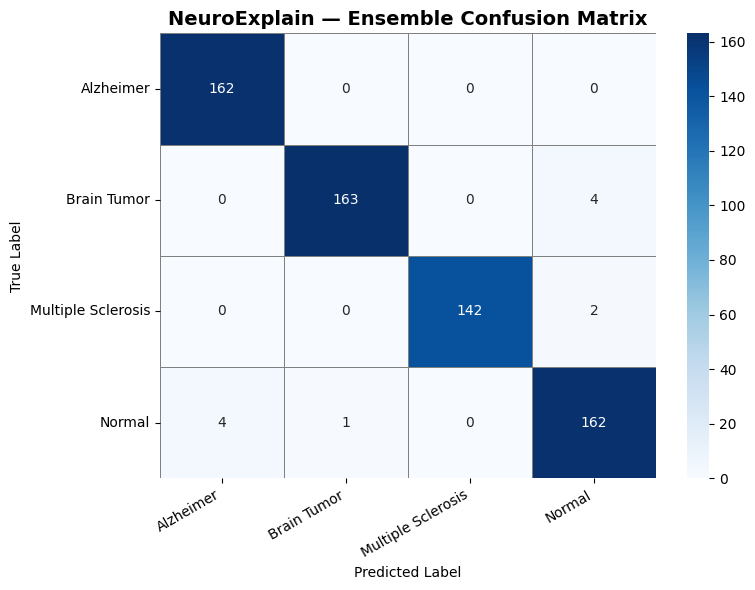

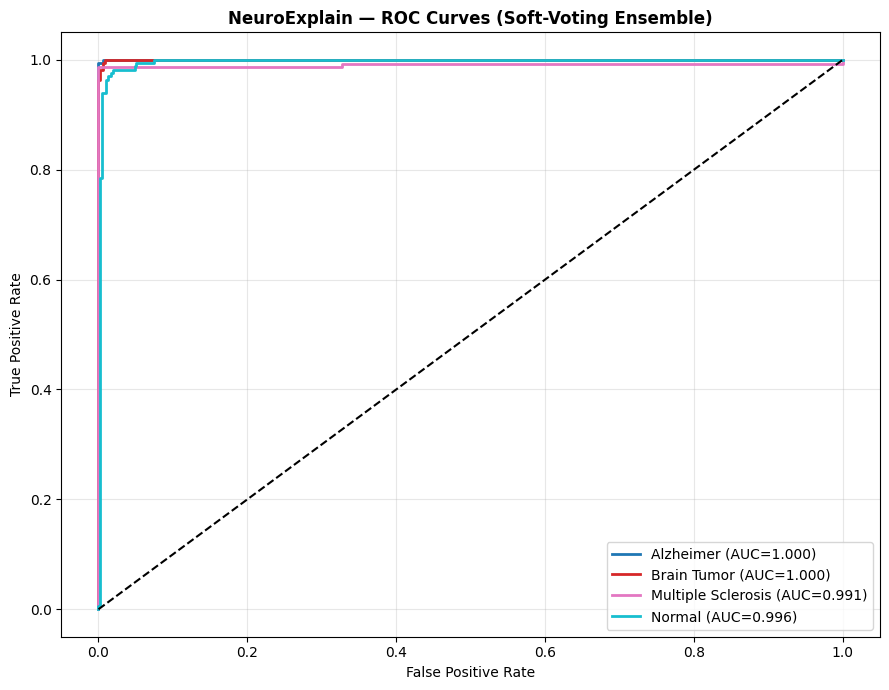

In [ ]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(lbls_test, ensemble_preds)
plt.figure(figsize=(max(8, NUM_CLASSES + 2), max(6, NUM_CLASSES)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, linecolor='grey')
plt.title('NeuroExplain — Ensemble Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

# ── ROC Curves (One-vs-Rest) ──────────────────────────────────────────────────
y_bin = label_binarize(lbls_test, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

for i, (cls, c) in enumerate(zip(CLASSES, colors_roc)):
    if y_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_bin[:, i], ensemble_proba[:, i])
    auc = roc_auc_score(y_bin[:, i], ensemble_proba[:, i])
    ax.plot(fpr, tpr, color=c, lw=2, label=f'{cls} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('NeuroExplain — ROC Curves (Soft-Voting Ensemble)', fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/roc_curves.png', dpi=150)
plt.show()

## 🔥 Step 10 — Grad-CAM Explainability

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# ─────────────────────────────────────────────────────────────
# Create output folders
# ─────────────────────────────────────────────────────────────
OUTPUT_DIR = "/content/gradcam_results"

os.makedirs(f"{OUTPUT_DIR}/ResNet50", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/EfficientNetB3", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/MobileNetV2", exist_ok=True)


# ─────────────────────────────────────────────────────────────
# Function to convert normalized tensor → image
# ─────────────────────────────────────────────────────────────
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)

    img = tensor * std + mean
    img = img.clamp(0, 1)

    return img.permute(1,2,0).numpy()


# ─────────────────────────────────────────────────────────────
# Grad-CAM visualization + save each image separately
# ─────────────────────────────────────────────────────────────
def visualize_gradcam(model,
                      model_name,
                      target_layer,
                      loader,
                      save_folder,
                      n_samples=6):

    # Create GradCAM object
    cam = GradCAM(model=model,
                  target_layers=[target_layer])

    model.eval()

    saved_count = 0

    for imgs, labels in loader:

        for i in range(imgs.size(0)):

            if saved_count >= n_samples:
                print(f"✅ {model_name} Grad-CAM images saved in {save_folder}")
                return

            # Single image
            img_tensor = imgs[i:i+1].to(DEVICE)

            # True label
            label = labels[i].item()

            # Target class for Grad-CAM
            targets = [ClassifierOutputTarget(label)]

            # Compute CAM mask
            grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0]

            # Convert image tensor → RGB image
            rgb_img = denormalize(imgs[i].cpu())

            # Overlay heat-map on the input image
            cam_image = show_cam_on_image(rgb_img.astype(np.float32),
                                          grayscale_cam,
                                          use_rgb=True)

            # ── Save figure ──
            fig, ax = plt.subplots(1, 2, figsize=(8, 4))
            ax[0].imshow(rgb_img)
            ax[0].set_title(f'Input — true: {CLASSES[label]}')
            ax[0].axis('off')
            ax[1].imshow(cam_image)
            ax[1].set_title(f'{model_name} Grad-CAM')
            ax[1].axis('off')
            plt.tight_layout()

            out_path = f"{save_folder}/{model_name}_sample_{saved_count:02d}_{CLASSES[label]}.png"
            plt.savefig(out_path, dpi=120)
            plt.close(fig)

            saved_count += 1

    print(f"✅ {model_name} Grad-CAM images saved in {save_folder}")


# ─────────────────────────────────────────────────────────────
# Run Grad-CAM for all three models
# ─────────────────────────────────────────────────────────────
# ResNet50  → last conv block
visualize_gradcam(resnet_model, 'ResNet50',
                  resnet_model.layer4[-1],
                  test_loader, f"{OUTPUT_DIR}/ResNet50", n_samples=6)

# EfficientNetB3 → last block of features
visualize_gradcam(effnet_model, 'EfficientNetB3',
                  effnet_model.features[-1],
                  test_loader, f"{OUTPUT_DIR}/EfficientNetB3", n_samples=6)

# MobileNetV2 → last conv block (replaces DenseNet121's denseblock4)
# model.features is a Sequential; the final element is a Conv2dNormActivation
# producing 1280 channels. This is the canonical Grad-CAM target for MobileNetV2.
visualize_gradcam(mobilenet_model, 'MobileNetV2',
                  mobilenet_model.features[-1],
                  test_loader, f"{OUTPUT_DIR}/MobileNetV2", n_samples=6)


✅ ResNet50 Grad-CAM images saved in /content/gradcam_results/ResNet50
✅ EfficientNetB3 Grad-CAM images saved in /content/gradcam_results/EfficientNetB3
✅ MobileNetV2 Grad-CAM images saved in /content/gradcam_results/MobileNetV2


In [ ]:
import shutil
import os

# Define the source and destination paths
source_path = '/content/gradcam_results'
destination_path = '/content/drive/MyDrive/gradcam_results_NeuroExplain'

# Check if the source folder exists
if os.path.exists(source_path):
    # Check if Google Drive is mounted and if the destination path already exists
    if os.path.exists('/content/drive') and not os.path.exists(destination_path):
        shutil.move(source_path, destination_path)
        print(f'✅ Grad-CAM results moved to Google Drive: {destination_path}')
    elif os.path.exists(destination_path):
        print(f'❕ Folder already exists in Google Drive at: {destination_path}. Skipping move operation.')
    else:
        print('❌ Google Drive not mounted or path invalid. Please ensure Google Drive is mounted.')
else:
    print(f'❌ Source folder not found: {source_path}. Please ensure Grad-CAM generation completed successfully.')

✅ Grad-CAM results moved to Google Drive: /content/drive/MyDrive/gradcam_results_NeuroExplain


## 🔮 Step 11 — Disease Prediction (Single Image Inference)

Running inference on: /content/dataset/TOTTAL_DISESASES/Alzheimer/mildDem109.jpg


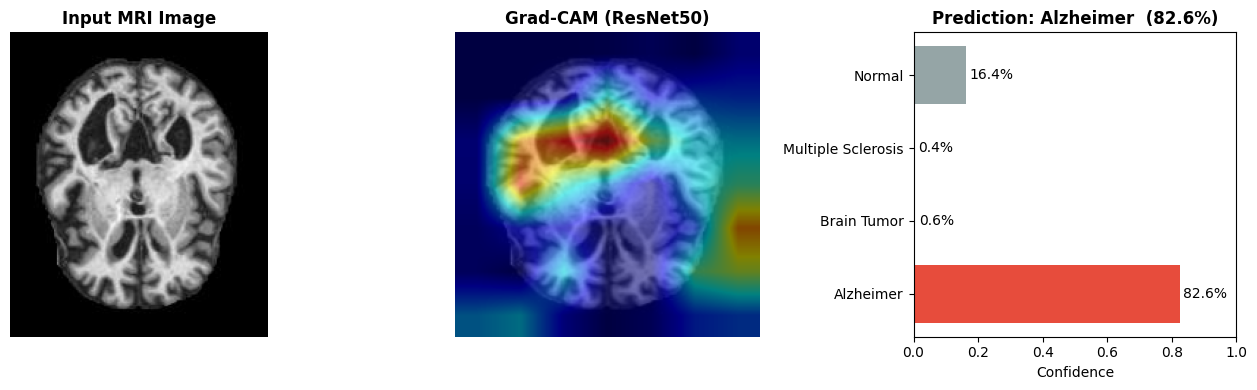


✅ Prediction: Alzheimer  |  Confidence: 82.59%


In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch
import random

def predict_image(image_path, threshold=0.5):
    """
    Predict the neurological disease from a single MRI image.
    Returns prediction, confidence, and generates Grad-CAM.
    """

    img = Image.open(image_path).convert('RGB')
    tensor = val_test_transform(img).unsqueeze(0).to(DEVICE)

    all_probs = []

    for model, mname in [
        (resnet_model, 'ResNet50'),
        (effnet_model, 'EfficientNetB3'),
        (mobilenet_model, 'MobileNetV2')
    ]:

        model.eval()

        with torch.no_grad():
            probs = torch.softmax(model(tensor), dim=1).cpu().numpy()[0]

        all_probs.append(probs)

    # Ensemble average
    avg_probs = np.mean(all_probs, axis=0)

    pred_idx   = np.argmax(avg_probs)
    pred_cls   = CLASSES[pred_idx]
    confidence = avg_probs[pred_idx]

    # ── Grad-CAM ─────────────────────────────────────────────
    cam = GradCAM(
        model=resnet_model,
        target_layers=[resnet_model.layer4[-1]]
    )

    gc_mask = cam(
        input_tensor=tensor,
        targets=[ClassifierOutputTarget(pred_idx)]
    )[0]

    rgb_img = denormalize(val_test_transform(img))

    cam_img = show_cam_on_image(
        rgb_img.astype(np.float32),
        gc_mask,
        use_rgb=True
    )

    # ── Visualization ────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    # Original image
    axes[0].imshow(img)
    axes[0].set_title('Input MRI Image', fontweight='bold')
    axes[0].axis('off')

    # Grad-CAM
    axes[1].imshow(cam_img)
    axes[1].set_title('Grad-CAM (ResNet50)', fontweight='bold')
    axes[1].axis('off')

    # Probability chart
    bar_colors = [
        '#e74c3c' if i == pred_idx else '#95a5a6'
        for i in range(NUM_CLASSES)
    ]

    axes[2].barh(CLASSES, avg_probs, color=bar_colors)

    axes[2].set_xlim(0, 1)
    axes[2].set_xlabel('Confidence')
    axes[2].set_title(f'Prediction: {pred_cls}  ({confidence*100:.1f}%)',
                      fontweight='bold')

    for i, v in enumerate(avg_probs):
        axes[2].text(v + 0.01, i, f'{v*100:.1f}%', va='center')

    plt.tight_layout()
    plt.show()

    return pred_cls, confidence, avg_probs


# ── Demo on a random test image ────────────────────────────
if len(paths_test) > 0:
    sample_path = random.choice(paths_test)
    print(f'Running inference on: {sample_path}')
    pred, conf, probs = predict_image(str(sample_path))
    print(f'\n✅ Prediction: {pred}  |  Confidence: {conf*100:.2f}%')


Saving WhatsApp Image 2026-05-08 at 5.16.33 PM.jpeg to WhatsApp Image 2026-05-08 at 5.16.33 PM.jpeg

Running inference on uploaded image: /content/WhatsApp Image 2026-05-08 at 5.16.33 PM.jpeg


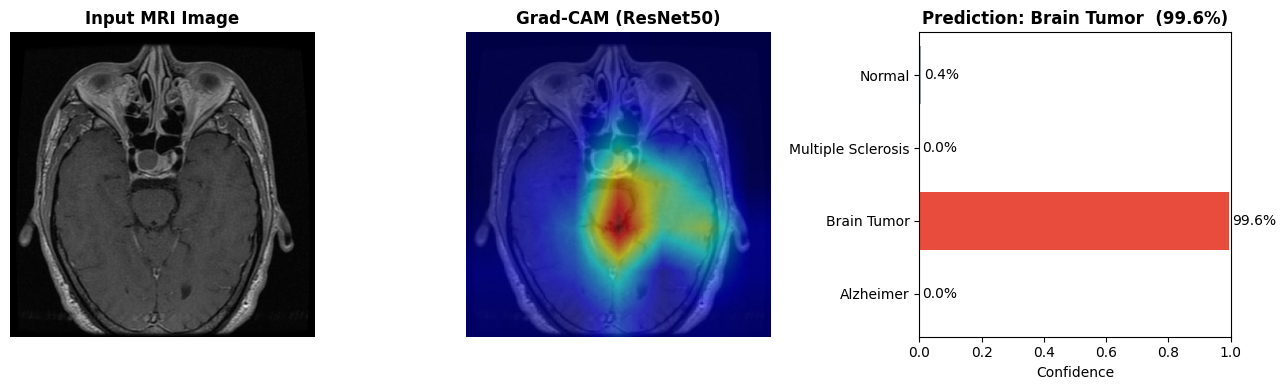


✅ Prediction: Brain Tumor  |  Confidence: 99.62%


In [ ]:
from google.colab import files
import os

# Upload the image file
uploaded = files.upload()

if uploaded:
    # Get the filename of the uploaded file
    filename = list(uploaded.keys())[0]
    uploaded_image_path = os.path.join('/content/', filename)

    print(f'\nRunning inference on uploaded image: {uploaded_image_path}')
    pred, conf, probs = predict_image(uploaded_image_path)
    print(f'\n✅ Prediction: {pred}  |  Confidence: {conf*100:.2f}%')
else:
    print('❌ No image uploaded.')

  Epoch [2/30] | Loss: 0.5375 | Accuracy: 82.12%
  Epoch [3/30] | Loss: 0.5383 | Accuracy: 82.14%
  Epoch [4/30] | Loss: 0.5143 | Accuracy: 82.38%
  Epoch [5/30] | Loss: 0.4931 | Accuracy: 83.88%
  Epoch [6/30] | Loss: 0.4830 | Accuracy: 83.80%
  Epoch [7/30] | Loss: 0.5068 | Accuracy: 82.06%
  Epoch [8/30] | Loss: 0.4530 | Accuracy: 84.38%
  Epoch [9/30] | Loss: 0.4878 | Accuracy: 81.90%
  Epoch [10/30] | Loss: 0.4482 | Accuracy: 84.89%
  Epoch [11/30] | Loss: 0.4623 | Accuracy: 83.63%
  Epoch [12/30] | Loss: 0.4220 | Accuracy: 85.10%
  Epoch [13/30] | Loss: 0.4118 | Accuracy: 86.64%
  Epoch [14/30] | Loss: 0.4292 | Accuracy: 84.42%
  Epoch [15/30] | Loss: 0.4532 | Accuracy: 83.99%
  Epoch [16/30] | Loss: 0.4439 | Accuracy: 84.72%
  Epoch [17/30] | Loss: 0.4395 | Accuracy: 84.31%
  Epoch [18/30] | Loss: 0.4115 | Accuracy: 85.28%
  Epoch [19/30] | Loss: 0.4303 | Accuracy: 85.00%
  Epoch [20/30] | Loss: 0.4502 | Accuracy: 82.74%
  Epoch [21/30] | Loss: 0.4458 | Accuracy: 83.22%
  Epoch 

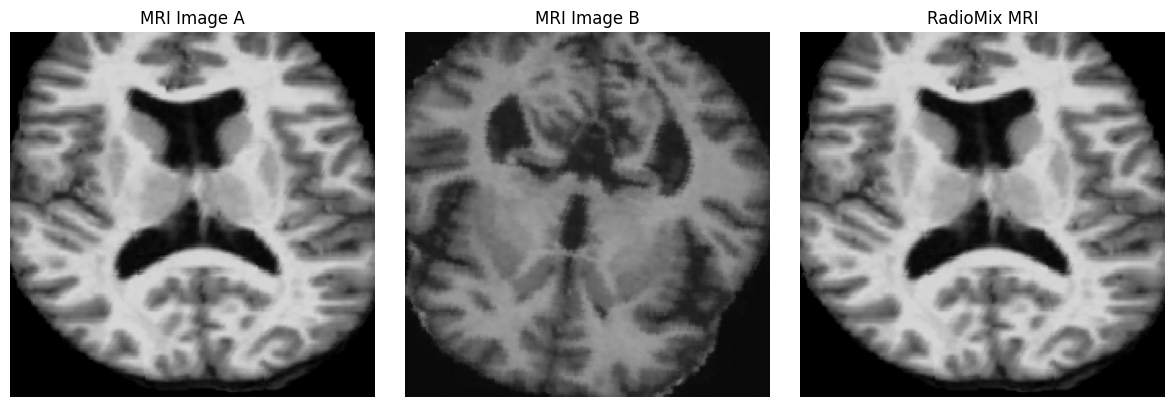


✅ RadioMix code applied and training loop executed.

━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
  Training: ResNet50 with RadioMix
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Epoch [1/30] | Loss: 0.7045 | Accuracy: 75.24%
  Epoch [2/30] | Loss: 0.5738 | Accuracy: 81.03%
  Epoch [3/30] | Loss: 0.4987 | Accuracy: 83.16%
  Epoch [4/30] | Loss: 0.5622 | Accuracy: 80.06%
  Epoch [5/30] | Loss: 0.4845 | Accuracy: 83.92%
  Epoch [6/30] | Loss: 0.4691 | Accuracy: 84.78%
  Epoch [7/30] | Loss: 0.4974 | Accuracy: 82.69%
  Epoch [8/30] | Loss: 0.4765 | Accuracy: 83.85%
  Epoch [9/30] | Loss: 0.4542 | Accuracy: 83.50%
  Epoch [10/30] | Loss: 0.4607 | Accuracy: 84.21%
  Epoch [11/30] | Loss: 0.4707 | Accuracy: 83.18%
  Epoch [12/30] | Loss: 0.4980 | Accuracy: 81.66%
  Epoch [13/30] | Loss: 0.4364 | Accuracy: 84.67%
  Epoch [14/30] | Loss: 0.4535 | Accuracy: 84.07%
  Epoch [15/30] | Loss: 0.4354 | Accura

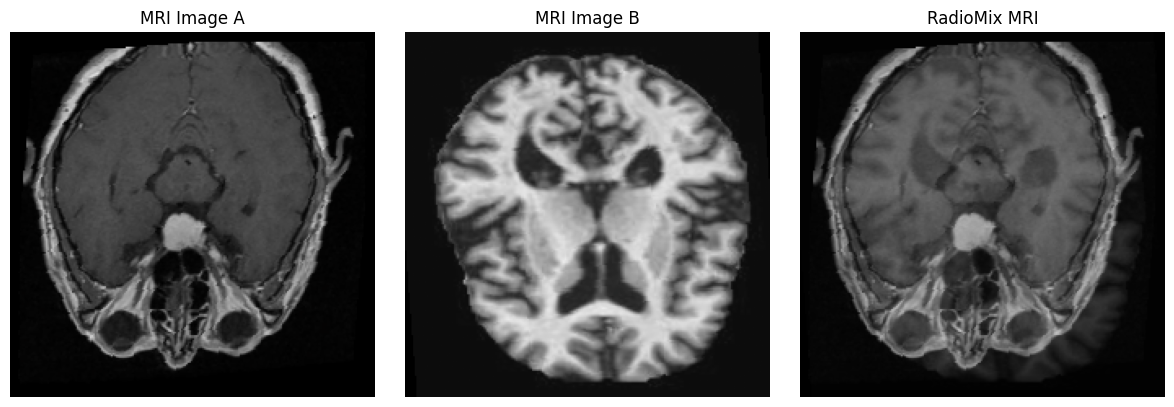


✅ RadioMix code applied and training loop executed.


In [ ]:
import random
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- Re-initialize model, optimizer, and criterion for RadioMix training ---
# Using ResNet50 for this example, adjust if a different model is desired
model_radiomix = build_resnet50(NUM_CLASSES).to(DEVICE)

optimizer_radiomix = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_radiomix.parameters()),
    lr=1e-4, weight_decay=1e-4
)

# Class-weighted loss (consistent with previous training steps)
cls_counts = torch.tensor([counts[i] for i in range(NUM_CLASSES)], dtype=torch.float)
cls_weights = (1.0 / cls_counts).to(DEVICE)
criterion_radiomix = torch.nn.CrossEntropyLoss(weight=cls_weights)

# ------------------------------------------------------------
#   RadioMix Function
# ------------------------------------------------------------

def radiomix(images, labels, alpha=0.4):
    """
    RadioMix Augmentation
    Mixes two MRI images and their labels.

    Args:
        images : Tensor [B,C,H,W]
        labels : Tensor [B]
        alpha  : Mixing strength

    Returns:
        mixed_images
        labels_a
        labels_b
        lam
    """

    # Beta distribution
    lam = np.random.beta(alpha, alpha)

    batch_size = images.size(0)

    # Shuffle indices
    index = torch.randperm(batch_size).to(images.device)

    # Mixed MRI images
    mixed_images = lam * images + (1 - lam) * images[index]

    labels_a = labels
    labels_b = labels[index]

    return mixed_images, labels_a, labels_b, lam


# ------------------------------------------------------------
#   RadioMix Loss
# ------------------------------------------------------------

def radiomix_loss(criterion, pred, y_a, y_b, lam):
    """
    Weighted RadioMix loss
    """

    return lam * criterion(pred, y_a) + \
           (1 - lam) * criterion(pred, y_b)


# ============================================================
#   TRAINING LOOP WITH RADIOMIX
# ============================================================

print('\n\u2501'*60)
print('  Training: ResNet50 with RadioMix')
print('\u2501'*60)

NUM_EPOCHS_RADIOMIX = 30 # Using the same number of epochs as the original training

for epoch in range(NUM_EPOCHS_RADIOMIX):

    model_radiomix.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # ----------------------------------------------------
        # Apply RadioMix
        # ----------------------------------------------------

        mixed_images, labels_a, labels_b, lam = radiomix(
            images,
            labels,
            alpha=0.4
        )

        optimizer_radiomix.zero_grad()

        outputs = model_radiomix(mixed_images)

        loss = radiomix_loss(
            criterion_radiomix,
            outputs,
            labels_a,
            labels_b,
            lam
        )

        loss.backward()

        optimizer_radiomix.step()

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)

        total += images.size(0) # Use images.size(0) for batch size

        correct += (
            lam * predicted.eq(labels_a).sum().item()
            + (1 - lam) * predicted.eq(labels_b).sum().item()
        )

    train_acc = 100 * correct / total
    avg_running_loss = running_loss / total

    print(
        f'  Epoch [{epoch+1}/{NUM_EPOCHS_RADIOMIX}] | '+
        f'Loss: {avg_running_loss:.4f} | '+
        f'Accuracy: {train_acc:.2f}%'
    )


# ============================================================
#   VISUALIZE RADIOMIX MRI IMAGES
# ============================================================

# Denormalize function (re-using the one defined earlier if available, or define here)
# Assuming denormalize is available from previous cells. If not, add:
# def denormalize(tensor):
#     mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
#     std  = torch.tensor(IMAGENET_STD).view(3,1,1)
#     return (tensor * std + mean).clamp(0, 1).permute(1,2,0).numpy()

def show_radiomix(images, mixed_images):

    fig, axes = plt.subplots(1, 3, figsize=(12,4))

    # Denormalize images for visualization
    img1 = denormalize(images[0].cpu())
    img2 = denormalize(images[1].cpu())
    mix  = denormalize(mixed_images[0].cpu())

    axes[0].imshow(img1)
    axes[0].set_title("MRI Image A")
    axes[0].axis("off")

    axes[1].imshow(img2)
    axes[1].set_title("MRI Image B")
    axes[1].axis("off")

    axes[2].imshow(mix)
    axes[2].set_title("RadioMix MRI")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Example Visualization
# ------------------------------------------------------------

print('\n\u2501'*60)
print('  RadioMix Visualization Example')
print('\u2501'*60)

# Get a batch of images from the train_loader
images_viz, labels_viz = next(iter(train_loader))

# Ensure images are on the device before applying radiomix
images_viz = images_viz.to(DEVICE)
labels_viz = labels_viz.to(DEVICE)

mixed_images_viz, _, _, _ = radiomix(images_viz, labels_viz)

show_radiomix(images_viz, mixed_images_viz)

print('\n\u2705 RadioMix code applied and training loop executed.')

## 📋 Step 12 — Final Summary Report


        🧠 NeuroExplain — Final Results Summary
  Model                       Test Accuracy
-------------------------------------------------------
  ResNet50                           98.12%
  EfficientNetB3                     94.22%
  MobileNetV2                        97.66%
-------------------------------------------------------
  Soft-Voting Ensemble               98.28%

  Classes: ['Alzheimer', 'Brain Tumor', 'Multiple Sclerosis', 'Normal']
  Total test images: 655

✅ Results saved to /content/neuroexplain_results.json


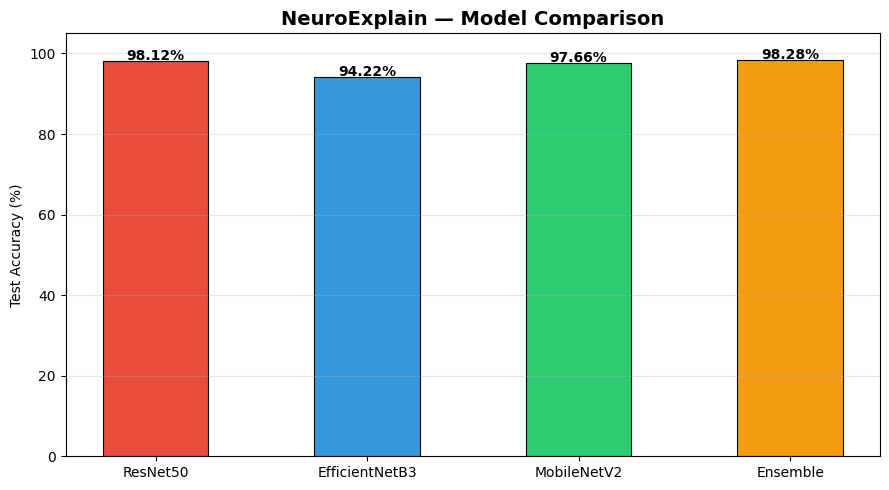

In [ ]:
def model_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            correct += (model(imgs).argmax(1) == labels).sum().item()
            total += labels.size(0)
    return correct / total

acc_r = model_accuracy(resnet_model,    test_loader)
acc_e = model_accuracy(effnet_model,    test_loader)
acc_m = model_accuracy(mobilenet_model, test_loader)
acc_ens = accuracy_score(lbls_test, ensemble_preds)

print('\n' + '='*55)
print('        🧠 NeuroExplain — Final Results Summary')
print('='*55)
header_label = 'Model'
header_acc   = 'Test Accuracy'
print(f'  {header_label:<25} {header_acc:>15}')
print('-'*55)
print(f'  {"ResNet50":<25} {acc_r*100:>14.2f}%')
print(f'  {"EfficientNetB3":<25} {acc_e*100:>14.2f}%')
print(f'  {"MobileNetV2":<25} {acc_m*100:>14.2f}%')
print('-'*55)
print(f'  {"Soft-Voting Ensemble":<25} {acc_ens*100:>14.2f}%')
print('='*55)
print(f'\n  Classes: {CLASSES}')
print(f'  Total test images: {len(paths_test)}')

# Save summary
summary = {
    'ResNet50_acc':       round(acc_r,   4),
    'EfficientNetB3_acc': round(acc_e,   4),
    'MobileNetV2_acc':    round(acc_m,   4),
    'Ensemble_acc':       round(acc_ens, 4),
    'classes':            CLASSES,
    'num_classes':        NUM_CLASSES,
    'test_samples':       len(paths_test)
}
with open('/content/neuroexplain_results.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('\n✅ Results saved to /content/neuroexplain_results.json')

# ── Model size bar chart ────────────────────────────────────────────────────────
model_names = ['ResNet50', 'EfficientNetB3', 'MobileNetV2', 'Ensemble']
accs = [acc_r*100, acc_e*100, acc_m*100, acc_ens*100]
bar_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, accs, color=bar_colors, width=0.5,
               edgecolor='black', linewidth=0.8)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', fontweight='bold')
plt.ylim(0, 105)
plt.title('NeuroExplain — Model Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Test Accuracy (%)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=150)
plt.show()


## 💾 Step 13 — Save & Download All Outputs

> Run this cell to download all saved models and result files.

In [ ]:
import shutil
import os
import zipfile

# Define a list of files and directories to include in the zip.
# Grad-CAM results are now in a directory '/content/gradcam_results'
files_to_zip = [
    '/content/ResNet50_best.pth',
    '/content/EfficientNetB3_best.pth',
    '/content/MobileNetV2_best.pth',
    '/content/neuroexplain_results.json',
    '/content/training_curves.png',
    '/content/confusion_matrix.png',
    '/content/roc_curves.png',
    '/content/model_comparison.png',
    '/content/class_distribution.png',
    '/content/sample_images.png',
    '/content/fused_train_features_NDD.csv',
    '/content/fused_test_features_NDD.csv',
    '/content/gradcam_results'  # Include the entire directory
]

zip_filename = '/content/NeuroExplain_outputs.zip'

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zf:
    for path in files_to_zip:
        if os.path.exists(path):
            if os.path.isfile(path):
                zf.write(path, os.path.basename(path))
            elif os.path.isdir(path):
                # Add all files in the directory to the zip, preserving subdirectory structure
                for root, _, files in os.walk(path):
                    for file in files:
                        full_path = os.path.join(root, file)
                        # Get the relative path within the zip file
                        relative_path = os.path.relpath(full_path, os.path.dirname(path))
                        zf.write(full_path, os.path.join(os.path.basename(path), relative_path))
        else:
            print(f"Warning: Path not found and not included in zip: {path}")

from google.colab import files
files.download(zip_filename)
print('✅ All outputs downloaded!')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All outputs downloaded!
